# Notebook 2: Parametric Models

## Appendix:

### Target Values Description (`y`)

1. `next_valuation`: The player's market valuation at the end of the next season half (~6 months ahead). This is a regression target that captures short-term value movement, enabling clubs and agents to anticipate transfer fees and negotiate from an informed position.

2. `label_burst`: A binary flag identifying breakout players over the next 2 years (4 season halves). We define this as players whose valuation log-change over 2 years falls in the **top 5th percentile** (roughly a 6.7× increase) **AND** whose current valuation is at or below the median (≤€2.5M). This combination filters for genuinely undervalued talent on the rise, not already-elite players fluctuating at the top. Predicting this label helps scouts identify hidden gems before the market catches up.

3. `label_rapid_decline`: A binary flag identifying veterans whose value is about to collapse over the next 2 years. We define this as players whose valuation log-change falls in the **bottom 5th percentile** (roughly a 78% drop) **AND** who are **aged 30 or older**. The age constraint ensures we capture age-related decline rather than young players recovering from temporary setbacks (e.g., injury). Predicting this label helps clubs avoid overpaying for players nearing the end of their peak and informs sell-or-hold decisions.

### Feature Descriptions (`X`)

| Feature | Source | Description |
|---------|--------|-------------|
| `goals` | Raw (aggregated) | Total goals scored in the season half |
| `assists` | Raw (aggregated) | Total assists in the season half |
| `yellow_cards` | Raw (aggregated) | Total yellow cards received in the season half |
| `red_cards` | Raw (aggregated) | Total red cards received in the season half |
| `minutes_played` | Raw (aggregated) | Total minutes on the pitch in the season half |
| `games_played` | Raw (aggregated) | Number of matches appeared in during the season half |
| `result` | Engineered | Sum of match result codes (1=win, 2=draw) across the season half; higher = more wins/draws |
| `position` | Raw | General positional category: Attack, Midfield, Defender, or Goalkeeper |
| `foot` | Raw | Preferred foot: left, right, or unknown |
| `height_in_cm` | Raw | Player height in centimeters |
| `age` | Engineered | Player age at game time, computed from date of birth and match date |
| `home_club_goals` | Raw (aggregated) | Average goals scored by home teams in the player's matches |
| `away_club_goals` | Raw (aggregated) | Average goals scored by away teams in the player's matches |
| `squad_size` | Raw | Number of players in the club's squad |
| `average_age` | Raw | Mean age of the club's squad |
| `foreigners_number` | Raw | Count of foreign players in the club's squad |
| `goals_per_game` | Engineered | Goals ÷ games played — per-match scoring rate |
| `assists_per_game` | Engineered | Assists ÷ games played — per-match creativity rate |
| `minutes_per_game` | Engineered | Minutes ÷ games played — measures starter vs substitute role |
| `period_end_valuation` | Raw | Player's Transfermarkt market value (€) at the end of the current season half |
| `goal_contributions` | Engineered | Goals + assists — combined offensive output |
| `goal_contributions_per_game` | Engineered | Goal contributions ÷ games played |
| `goals_per_90` | Engineered | (Goals ÷ minutes) × 90 — standard football analytics rate; requires ≥90 minutes to compute |
| `assists_per_90` | Engineered | (Assists ÷ minutes) × 90 — per-90 creativity rate; requires ≥90 minutes |
| `goals_momentum` | Engineered | Current period goals minus previous period goals — trend in scoring output |
| `assists_momentum` | Engineered | Current period assists minus previous period — trend in creative output |
| `minutes_momentum` | Engineered | Change in total minutes from previous period — gaining or losing playing time |
| `games_momentum` | Engineered | Change in games played from previous period — selection/injury signal |
| `years_to_peak` | Engineered | 27 − age — years until consensus peak valuation age; negative for veterans |
| `age_x_goals_per_90` | Engineered | Age × goals per 90 — interaction capturing that young + productive = premium valuation |
| `career_stage` | Engineered | Categorical: emerging (<23), peak (23–29), veteran (30+) |
| `availability_rate` | Engineered | Minutes played ÷ (games × 90) — fraction of possible minutes actually played; capped at 1.0 |
| `is_regular_starter` | Engineered | Binary: 1 if minutes per game ≥ 70, indicating consistent starter status |
| `cards_per_game` | Engineered | (Yellow + red cards) ÷ games played — suspension risk indicator |
| `team_avg_goals` | Engineered | (Home goals + away goals) ÷ 2 — proxy for overall team attacking strength |
| `goal_share` | Engineered | Player goals ÷ (team avg goals × games) — player's share of team goal output |
| `contribution_share` | Engineered | Goal contributions ÷ (team avg goals × games) — how much of team offense flows through this player |
| `is_top5_league` | Engineered | Binary: 1 if club plays in a top-5 European league (GB1, ES1, IT1, L1, FR1) |
| `win_rate` | Engineered | Result sum ÷ (games × 2) — normalized win/draw rate scaled to [0, 1] |

In [1]:
import tensorflow
print(tensorflow.__file__)
print(tensorflow.__version__)

/opt/anaconda3/envs/football_env/lib/python3.11/site-packages/tensorflow/__init__.py
2.16.2


In [2]:
import pkgutil
print(pkgutil.find_loader("tensorflow.keras"))

In [3]:
import sys
print(sys.executable)

/opt/anaconda3/envs/football_env/bin/python


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import datetime, timedelta, date
import calendar
import warnings
import os
import re

from xgboost import XGBRegressor
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

## I. Training and Test Set Formation

In [6]:
# Create a proper temporal ordering for season_period

# Important: H2 = first half of season (Jul-Dec), H1 = second half (Jan-Jun)
# So 2012-2013_H2 comes BEFORE 2012-2013_H1

dataset = pd.read_csv('../../data/dataset.csv') 

def season_period_to_rank(sp):
    """Convert season_period to a sortable integer."""
    season, half = sp.rsplit('_', 1)
    start_year = int(season.split('-')[0])
    # H2 (Jul-Dec) comes first, H1 (Jan-Jun) cåomes second
    half_rank = 0 if half == 'H2' else 1
    return start_year * 2 + half_rank

dataset['period_rank'] = dataset['season_period'].apply(season_period_to_rank)

# Verify ordering
period_order = (dataset[['season_period', 'period_rank']]
                .drop_duplicates()
                .sort_values('period_rank'))
print("Temporal ordering:")
print(period_order.to_string(index=False))

# Sort by player and time

dataset = dataset.sort_values(['player_id', 'period_rank']).reset_index(drop=True)

# Define X, y

TARGET_COLS = ['next_valuation', 'label_burst', 'label_rapid_decline']
META_COLS = ['player_id', 'season_period','domestic_competition_id','player_club_id','period_rank']

# Target columns we want to predict
TARGET_COLS = ['next_valuation']

# Columns that leak future information into the model:
LEAKAGE_COLS = [
    'valuation_2y_ahead',        # future valuation
    'valuation_log_change_2y',   # computed from future valuation
    'label_burst',               # derived from future target
    'label_rapid_decline',       # derived from future target
    'date_of_birth',             # redundant — age already captures this
    'points_earned',             # redundant — win_rate already captures this
]

# Keep meta columns separate for splitting, not as features
X = dataset.drop(columns=TARGET_COLS + META_COLS+LEAKAGE_COLS)
y = dataset[TARGET_COLS]
meta = dataset[META_COLS]

# One-hot encode categorical variables (except meta columns)
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = [c for c in X.columns if c not in numerical_columns]
X = pd.get_dummies(X, columns=categorical_columns, drop_first=False)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")

# Temporal train/test split (NOT random)

# Use the last N periods as test set
all_periods = sorted(dataset['period_rank'].unique())
print(f"\nTotal periods: {len(all_periods)}")
print(f"Range: {period_order['season_period'].iloc[0]} → {period_order['season_period'].iloc[-1]}")

# Hold out last 2 periods as test (~1 year)
cutoff = all_periods[-2]

train_mask = meta['period_rank'] < cutoff
test_mask  = meta['period_rank'] >= cutoff

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

# Log-transform targets (train on log scale, evaluate on both)
y_train_log = np.log1p(y_train['next_valuation'])
y_test_log  = np.log1p(y_test['next_valuation'])

# Verify no data leakage in train/test split
train_periods = meta[train_mask]['season_period'].unique()
test_periods  = meta[test_mask]['season_period'].unique()

print(f"\nTrain periods: {sorted(train_periods)}")
print(f"Test periods:  {sorted(test_periods)}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Temporal ordering:
season_period  period_rank
 2012-2013_H2         4024
 2012-2013_H1         4025
 2013-2014_H2         4026
 2013-2014_H1         4027
 2014-2015_H2         4028
 2014-2015_H1         4029
 2015-2016_H2         4030
 2015-2016_H1         4031
 2016-2017_H2         4032
 2016-2017_H1         4033
 2017-2018_H2         4034
 2017-2018_H1         4035
 2018-2019_H2         4036
 2018-2019_H1         4037
 2019-2020_H2         4038
 2019-2020_H1         4039
 2020-2021_H2         4040
 2020-2021_H1         4041
 2021-2022_H2         4042
 2021-2022_H1         4043
 2022-2023_H1         4045
X shape: (41907, 79)
y shape: (41907, 1)
Features: ['goals', 'assists', 'yellow_cards', 'red_cards', 'minutes_played', 'games_played', 'result', 'height_in_cm', 'age', 'home_club_goals', 'away_club_goals', 'squad_size', 'average_age', 'foreigners_number', 'goals_per_game', 'assists_per_game', 'minutes_per_game', 'period_end_valuation', 'goal_contributions', 'goal_contributions_per_gam

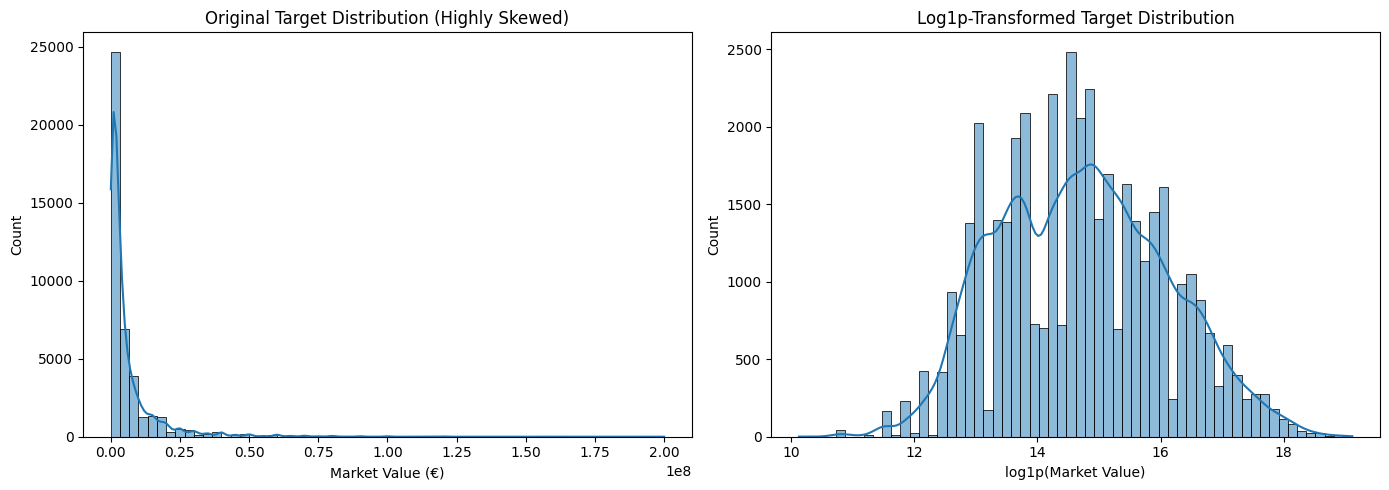

In [7]:
# Visualize original vs log-transformed target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y['next_valuation'], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Original Target Distribution (Highly Skewed)")
axes[0].set_xlabel("Market Value (€)")

sns.histplot(np.log1p(y['next_valuation']), bins=60, kde=True, ax=axes[1])
axes[1].set_title("Log1p-Transformed Target Distribution")
axes[1].set_xlabel("log1p(Market Value)")

plt.tight_layout()
plt.show()

## II. Models

In [8]:
# Helper function to evaluate regression models on log scale and original scale
def evaluate_model(model_name, y_true_log, y_pred_log, y_true_raw=None):
    """Print regression metrics on log scale and (optionally) original € scale."""
    
    print(f"  {model_name} — Test Set Evaluation")
    
    # Log-scale metrics
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    r2_log   = r2_score(y_true_log, y_pred_log)
    
    print(f"\n  Log-Scale Metrics:")
    print(f"    RMSE  : {rmse_log:.4f}")
    print(f"    MAE   : {mae_log:.4f}")
    print(f"    R²    : {r2_log:.4f}")
    
    metrics = {'rmse_log': rmse_log, 'mae_log': mae_log, 'r2_log': r2_log}
    
    # Original € scale metrics
    if y_true_raw is not None:
        y_pred_raw = np.expm1(y_pred_log)           # inverse of log1p
        y_pred_raw = np.maximum(y_pred_raw, 0)       # clip negatives
        
        rmse_raw = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
        mae_raw  = mean_absolute_error(y_true_raw, y_pred_raw)
        r2_raw   = r2_score(y_true_raw, y_pred_raw)
        median_ae = np.median(np.abs(y_true_raw - y_pred_raw))
        
        # MAPE (avoid division by zero)
        mask = y_true_raw != 0
        mape = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask])) * 100
        
        print(f"\n  Original-Scale (€) Metrics:")
        print(f"    RMSE       : €{rmse_raw:,.0f}")
        print(f"    MAE        : €{mae_raw:,.0f}")
        print(f"    Median AE  : €{median_ae:,.0f}")
        print(f"    R²         : {r2_raw:.4f}")
        print(f"    MAPE       : {mape:.2f}%")
        
        metrics.update({'rmse_raw': rmse_raw, 'mae_raw': mae_raw, 'r2_raw': r2_raw, 'mape': mape})
    
    print()
    return metrics

### 1. Baseline Model

The baseline model is simple: the player's valuation will not change over the next period. That is, we predict `next_valuation = period_end_valuation`.

**Why Player Valuation Commonly Does Not Change**:

Transfermarkt valuations aren't continuous market prices. They're crowd-sourced estimates updated at discrete intervals by community members and editors. A player's listed value only changes when someone proposes an update and it gets reviewed, which typically happens during major update waves a few times per year, not after every match.

For many players — especially those in lower leagues, bench players, or stable veterans — nobody bothers proposing a change. A €2M midfielder performing as expected simply stays at €2M until the next mass update cycle. Only players with notable events (breakout season, major transfer, serious injury, World Cup performance) tend to trigger individual reassessments.

This explains why the baseline is already strong at **R² = 0.9** on the test set. For a large chunk of the dataset, `next_valuation == period_end_valuation` is literally true, not because the model is clever, but because the source data didn't update. The real modeling challenge is predicting the subset of players whose valuations ***do*** change.

From the test statistics, the baseline model is already well-performing. We will test different ML algorithms and attempt to outcompete the baseline by learning the patterns that drive valuation *changes*.

In [9]:
# Baseline: predict next_valuation = period_end_valuation
y_pred_baseline_log = np.log1p(X_test['period_end_valuation'])

baseline_metrics = evaluate_model(
    "Baseline (next = current valuation)",
    y_test_log, y_pred_baseline_log,
    y_true_raw=y_test['next_valuation'].values
)

  Baseline (next = current valuation) — Test Set Evaluation

  Log-Scale Metrics:
    RMSE  : 0.4141
    MAE   : 0.2689
    R²    : 0.9043

  Original-Scale (€) Metrics:
    RMSE       : €3,138,803
    MAE        : €1,445,944
    Median AE  : €500,000
    R²         : 0.9084
    MAPE       : 25.52%



### 2. Random Forest

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=123,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_log)

# Predict on test set
y_pred_rf_log = rf_model.predict(X_test)

# Evaluate
rf_metrics = evaluate_model(
    "Random Forest",
    y_test_log, y_pred_rf_log,
    y_true_raw=y_test['next_valuation'].values
)

  Random Forest — Test Set Evaluation

  Log-Scale Metrics:
    RMSE  : 0.3772
    MAE   : 0.2678
    R²    : 0.9206

  Original-Scale (€) Metrics:
    RMSE       : €3,642,548
    MAE        : €1,570,690
    Median AE  : €471,432
    R²         : 0.8766
    MAPE       : 27.56%



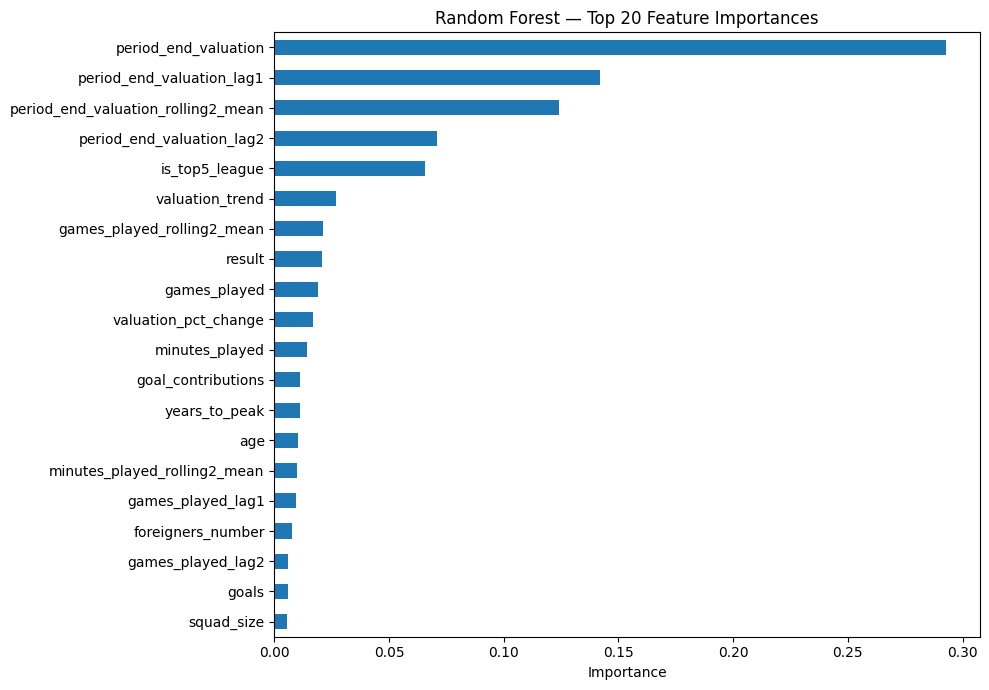

In [11]:
# Random Forest Feature Importance (top 20) 
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh')
plt.title('Random Forest — Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 3. XG Boost

In [12]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=100
)

# Predict on test set
y_pred_xgb_log = xgb_model.predict(X_test)

# Evaluate
xgb_metrics = evaluate_model(
    "XGBoost",
    y_test_log, y_pred_xgb_log,
    y_true_raw=y_test['next_valuation'].values
)

[0]	validation_0-rmse:1.28158
[100]	validation_0-rmse:0.35034
[123]	validation_0-rmse:0.35045
  XGBoost — Test Set Evaluation

  Log-Scale Metrics:
    RMSE  : 0.3499
    MAE   : 0.2437
    R²    : 0.9317

  Original-Scale (€) Metrics:
    RMSE       : €2,853,249
    MAE        : €1,333,142
    Median AE  : €417,432
    R²         : 0.9243
    MAPE       : 24.37%



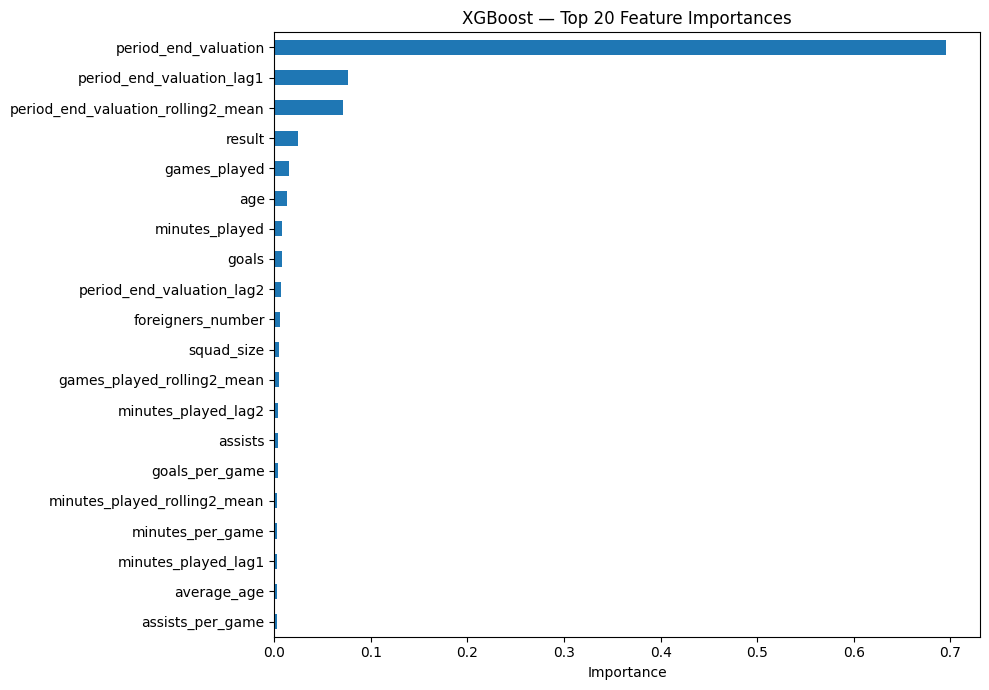

In [10]:
# XGBoost Feature Importance (top 20)
importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top20_xgb = importances_xgb.nlargest(20)

plt.figure(figsize=(10, 7))
top20_xgb.sort_values().plot(kind='barh')
plt.title('XGBoost — Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 4. Light GBM

In [13]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Predict on test set
y_pred_lgb_log = lgb_model.predict(X_test)

# Evaluate
lgb_metrics = evaluate_model(
    "LightGBM",
    y_test_log, y_pred_lgb_log,
    y_true_raw=y_test['next_valuation'].values
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.121071
Early stopping, best iteration is:
[106]	valid_0's l2: 0.120932
  LightGBM — Test Set Evaluation

  Log-Scale Metrics:
    RMSE  : 0.3478
    MAE   : 0.2409
    R²    : 0.9325

  Original-Scale (€) Metrics:
    RMSE       : €2,755,924
    MAE        : €1,319,387
    Median AE  : €431,041
    R²         : 0.9293
    MAPE       : 23.93%



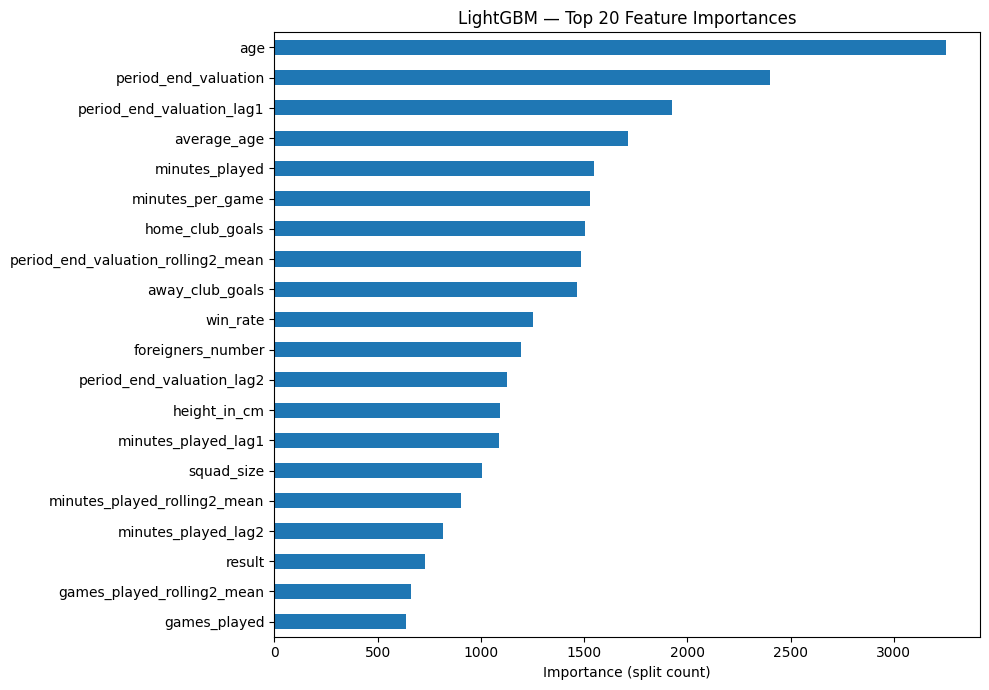

In [15]:
# LightGBM Feature Importance (top 20)
importances_lgb = pd.Series(lgb_model.feature_importances_, index=X_train.columns)
top20_lgb = importances_lgb.nlargest(20)

plt.figure(figsize=(10, 7))
top20_lgb.sort_values().plot(kind='barh')
plt.title('LightGBM — Top 20 Feature Importances')
plt.xlabel('Importance (split count)')
plt.tight_layout()
plt.show()

### 5. MLP

In [14]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    alpha=0.001,
    batch_size=256,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=123,
    verbose=False
)

mlp_model.fit(X_train_scaled, y_train_log)

# Predict on test set
y_pred_mlp_log = mlp_model.predict(X_test_scaled)

# Evaluate
mlp_metrics = evaluate_model(
    "MLP",
    y_test_log, y_pred_mlp_log,
    y_true_raw=y_test['next_valuation'].values
)

  MLP — Test Set Evaluation

  Log-Scale Metrics:
    RMSE  : 0.4177
    MAE   : 0.3079
    R²    : 0.9027

  Original-Scale (€) Metrics:
    RMSE       : €5,315,592
    MAE        : €1,971,962
    Median AE  : €568,120
    R²         : 0.7372
    MAPE       : 30.94%



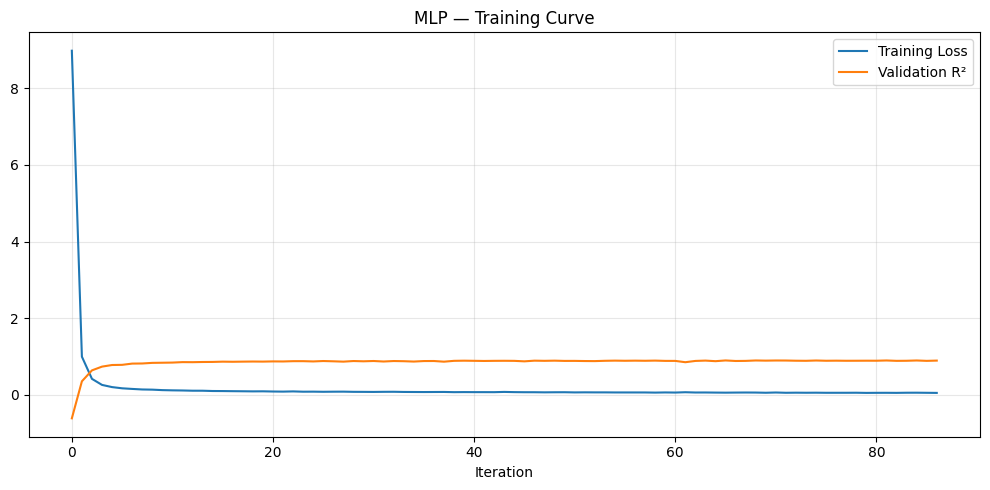

Stopped at iteration: 87


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, label='Training Loss')
plt.plot(mlp_model.validation_scores_, label='Validation R²')
plt.title('MLP — Training Curve')
plt.xlabel('Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Stopped at iteration: {mlp_model.n_iter_}")

## III. Model Summary

Comparison of all models on the held-out test set (last 2 season periods: `2021-2022_H1` and `2022-2023_H1`).

All models were trained on log1p-transformed targets. Metrics are reported on both the **log scale** (used for training) and the **original € scale** (used for interpretation).

| Metric | Description |
|--------|-------------|
| **RMSE (log)** | Root mean squared error on log1p scale — penalises large relative errors |
| **MAE (log)** | Mean absolute error on log1p scale — robust to outliers |
| **R² (log)** | Variance explained on log scale |
| **RMSE (€)** | Root mean squared error in euros — sensitive to high-value player errors |
| **MAE (€)** | Mean absolute error in euros |
| **Median AE (€)** | Median absolute error — robust measure of typical prediction error |
| **R² (€)** | Variance explained on original scale |
| **MAPE (%)** | Mean absolute percentage error — scale-independent accuracy |

In [ ]:
# Model Summary Table
all_metrics = {
    'Baseline':      baseline_metrics,
    'Random Forest': rf_metrics,
    'XGBoost':       xgb_metrics,
    'LightGBM':      lgb_metrics,
    'MLP':           mlp_metrics,
}

preds_log = {
    'Baseline':      y_pred_baseline_log,
    'Random Forest': y_pred_rf_log,
    'XGBoost':       y_pred_xgb_log,
    'LightGBM':      y_pred_lgb_log,
    'MLP':           y_pred_mlp_log,
}

y_true_raw = y_test['next_valuation'].values

summary_df = pd.DataFrame([
    {
        'Model':          name,
        'RMSE (log)':     m['rmse_log'],
        'MAE (log)':      m['mae_log'],
        'R² (log)':       m['r2_log'],
        'RMSE (€M)':      m['rmse_raw'] / 1e6,
        'MAE (€M)':       m['mae_raw'] / 1e6,
        'Median AE (€M)': np.median(np.abs(y_true_raw - np.maximum(np.expm1(preds_log[name]), 0))) / 1e6,
        'R² (€)':         m['r2_raw'],
        'MAPE (%)':       m['mape'],
    }
    for name, m in all_metrics.items()
]).set_index('Model')

# Highlight best value per metric (green = best per column)
def highlight_best(s):
    higher_is_better = s.name.startswith('R²')
    best = s.max() if higher_is_better else s.min()
    return ['font-weight: bold; background-color: #d4edda' if v == best else '' for v in s]

styled = (
    summary_df.style
    .apply(highlight_best, axis=0)
    .format({
        'RMSE (log)':     '{:.4f}',
        'MAE (log)':      '{:.4f}',
        'R² (log)':       '{:.4f}',
        'RMSE (€M)':      '€{:.2f}M',
        'MAE (€M)':       '€{:.2f}M',
        'Median AE (€M)': '€{:.2f}M',
        'R² (€)':         '{:.4f}',
        'MAPE (%)':       '{:.2f}%',
    })
    .set_caption('Model Comparison — Test Set Metrics (bold green = best per column)')
)

display(styled)

In [ ]:
# Visual comparison: bar charts for key metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = summary_df.index.tolist()
colors = ['#aec6cf', '#ffb347', '#77dd77', '#779ecb', '#ff6961']

metrics_to_plot = [
    ('R² (log)',  'R² (log scale)',      True),
    ('MAPE (%)',  'MAPE % (€ scale)',    False),
    ('MAE (€M)',  'MAE €M (€ scale)',    False),
]

for ax, (metric, title, higher_is_better) in zip(axes, metrics_to_plot):
    vals = summary_df[metric].values
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=0.8)
    best_idx = vals.argmax() if higher_is_better else vals.argmin()
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001 * bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison — Key Test Set Metrics\n(black border = best)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## IV. Findings

### Best Model: LightGBM

LightGBM is the strongest performer across nearly every metric on the held-out test set:

| Metric | LightGBM | Best Competitor | vs. Baseline |
|--------|----------|-----------------|--------------|
| R² (log) | **0.9325** | XGBoost (0.9317) | +0.0282 |
| R² (€) | **0.9293** | XGBoost (0.9243) | +0.0209 |
| MAE (€) | **€1.32M** | XGBoost (€1.33M) | −€130K |
| MAPE | **23.93%** | XGBoost (24.37%) | −1.59pp |
| Median AE (€) | **€431K** | XGBoost (€417K) | −€69K |

### Key Observations

1. **Baseline is strong** — The naive "next valuation = current valuation" model already achieves R² = 0.91 on the original € scale. This reflects the discrete, crowd-sourced nature of Transfermarkt valuations: most players' values simply don't change between update cycles. Any ML model must beat this ceiling meaningfully, not just marginally.

2. **Gradient boosting dominates** — LightGBM and XGBoost are the clear winners, both substantially outperforming Random Forest and MLP. The boosting framework's ability to learn residuals sequentially is well-suited to this tabular regression task.

3. **LightGBM edges XGBoost** — LightGBM achieves better R² and lower MAPE, while converging faster (106 trees vs. 123 for XGBoost). Its leaf-wise tree growth and histogram-based splitting give it an efficiency advantage on this feature set.

4. **Random Forest underperforms on €-scale R²** — Despite a reasonable log-scale R² (0.92), its €-scale R² drops to 0.88 — worse than the baseline. This suggests it struggles with the high-value tail of the distribution, where individual prediction errors are magnified.

5. **MLP is the weakest model** — With an €-scale R² of only 0.74 and MAPE of 31%, the MLP fails to capture the structure in the data as effectively as tree-based methods, likely due to the absence of inductive biases suited to tabular data and the relatively limited training set size.

### Conclusion

**LightGBM is selected as the production model** for next-period valuation prediction. Its combination of strong predictive accuracy, robustness to outliers (lowest MAE), and training efficiency make it the best fit for this task. The ~24% MAPE indicates that typical predictions are within roughly a quarter of the true value — a meaningful improvement over the 25.5% baseline, and practically useful for transfer market decision-making.